# Puzzle Solver – Ideen, Ansätze und Umsetzung

In diesem Projekt haben wir untersucht, wie man mithilfe von klassischer 2D-Computer-Vision einen Puzzle-Solver entwickeln kann – also.

Unser Ziel war es, eine Anwendung zu entwickeln, die visuell erkennt:
- welche Puzzleteile zusammengehören,
- oder wohin ein Teil im fertigen Puzzle gehört.


## Ideenphase: Was soll der Puzzle Solver können?

Wir haben zunächst verschiedene Anwendungsmöglichkeiten gesammelt:

1. 📷 **Zwei Puzzleteile fotografieren**  
   → Der Solver entscheidet, ob sie zusammengehören.

2. 🧩 **Viele Teile auf einmal fotografieren**  
   → Der Solver erkennt automatisch passende Puzzleteile.

3. 🖼️ **Einzelnes Teil + fertige Puzzle-Vorlage**  
   → Der Solver zeigt, wo das Teil im Gesamtbild hingehört.


## Umsetzungsideen 

Wir haben verschiedene Ansätze diskutiert:

### Idee 1: Formbasierte Kantenerkennung
- Annahme: Bei Erwachsenenpuzzles passen die Teile **nur durch die Form** zusammen.
- Ansatz: Kanten der Puzzleteile extrahieren und analysieren, ob zwei Kanten geometrisch zueinander passen (z. B. konvex ↔ konkav).

### Idee 2: Farbvergleich an den Rändern
- Idee: Vergleiche die **Farbverläufe entlang der Ränder** der Puzzleteile.
- Randbereiche extrahieren (z. B. als Streifen von 5–10 Pixeln) und RGB- oder HSV-Werte vergleichen.

### Idee 3: Lokalisierung durch Bildähnlichkeit
- Aufgabe: Ein einzelnes Puzzleteil soll in einem Bild des fertigen Puzzles lokalisiert werden.
- Lösung: Das Puzzleteil wird freigestellt und systematisch über das vollständige Bild geschoben.
- An jeder Position wird die Ähnlichkeit zwischen dem Teil und dem entsprechenden Ausschnitt des Gesamtbildes berechnet.
- Die Position mit der höchsten Übereinstimmung wird als wahrscheinliche Stelle für das Teil angenommen.


## Umsetzung von Idee 3: Teil im Gesamtbild finden

Als ersten Schritt für diese Variante mussten wir das einzelne Puzzleteil freistellen, um nur das Teil (ohne weißen Hintergrund) mit dem Gesamtbild vergleichen zu können.

Dazu haben wir eine einfache Punktoperation verwendet, die alle fast weißen Pixel (RGB-Werte über einem Schwellenwert) entfernt und durch Transparenz ersetzt.

So entsteht ein freigestelltes Puzzleteil mit Alpha-Kanal.


In [27]:
import numpy as np
import imageio.v3 as iio  # alternativ: matplotlib.image.imread

def remove_white_background(image_path: str, threshold: int = 240, save_path: str = None):
    """
    Entfernt weißen Hintergrund aus einem Bild und gibt ein RGBA-Bild zurück.
    Unterstützt .png und .jpg Formate.
    
    :param image_path: Pfad zum Eingabebild.
    :param threshold: Schwellenwert für Weiß (Standard: 240).
    :param save_path: Optionaler Pfad zum Speichern des RGBA-Bildes.
    :return: RGBA-Bild als NumPy-Array.
    """
    # 1. Bild einlesen
    img = iio.imread(image_path)

    # 2. In uint8 wandeln, falls nötig
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8)

    height, width, channels = img.shape

    # 3. Prüfen, ob Bild bereits einen Alpha-Kanal hat
    if channels == 4:
        rgb = img[..., :3]  # Nur RGB verwenden
    elif channels == 3:
        rgb = img
    else:
        raise ValueError(f"Unexpected number of channels: {channels}")

    # 4. Alpha-Kanal vorbereiten (255 = sichtbar)
    alpha = np.ones((height, width), dtype=np.uint8) * 255

    # 5. Punktweise prüfen: Ist der Pixel fast weiß?
    for y in range(height):
        for x in range(width):
            r, g, b = rgb[y, x]
            if r >= threshold and g >= threshold and b >= threshold:
                alpha[y, x] = 0  # Transparent machen

    # 6. RGBA-Bild zusammenbauen
    rgba = np.zeros((height, width, 4), dtype=np.uint8)
    rgba[..., :3] = rgb
    rgba[..., 3] = alpha

    # Optional: Bild speichern
    if save_path:
        iio.imwrite(save_path, rgba)

    return rgba

## Bildskalierung: Vorbereitung für den Rastervergleich

Um das Puzzleteil sinnvoll mit dem Gesamtpuzzle vergleichen zu können, müssen beide Bilder in **kompatiblen Größen** vorliegen.

Dazu haben wir zwei Funktionen entwickelt:

### 🔧 `resize_numpy_rgba_image`

Diese Funktion skaliert ein beliebiges RGBA-Bild auf eine gewünschte Breite (in Pixeln).  
Im Gegensatz zur ersten Version verwenden wir nun **OpenCV**, um effizienter und qualitativ hochwertiger zu interpolieren.

Die Funktionsweise:
- Die RGB-Kanäle werden mit **bilinearer Interpolation** (`INTER_LINEAR`) skaliert – das sorgt für weichere Übergänge.
- Der Alpha-Kanal wird mit **Nearest-Neighbor** (`INTER_NEAREST`) skaliert, um harte Transparenzgrenzen beizubehalten.
- Das Seitenverhältnis bleibt erhalten.

### 🧩 `resize_piece_to_fit_grid`

Diese Funktion sorgt dafür, dass das Puzzleteil genau die **Größe eines Rasterfelds** im Gesamtpuzzle bekommt. Das ist nötig, um das Teil später zellenweise vergleichen zu können.

Vorgehen:
1. Das Gesamtpuzzle wird auf eine einheitliche Zielbreite skaliert (z. B. 300 px).
2. Daraus wird berechnet, wie groß ein einzelnes Feld bei gegebener Spalten-/Zeilenzahl ist (z. B. bei 6 × 4).
3. Das Puzzleteil wird zunächst auf die passende Breite skaliert und ggf. in der Höhe noch einmal angepasst.
4. Auch hier wird OpenCV verwendet – für saubere und effiziente Skalierung.

Diese Vorbereitung ist entscheidend, um im nächsten Schritt das Puzzleteil über alle Felder des Gesamtbilds schieben und vergleichen zu können.


In [28]:
import numpy as np
import cv2

def resize_numpy_rgba_image(img: np.ndarray, new_width: int) -> np.ndarray:
    orig_h, orig_w = img.shape[:2]
    scale = new_width / orig_w
    new_h = int(orig_h * scale)

    # Bild und Alpha-Kanal separat behandeln
    rgb = img[..., :3]
    alpha = img[..., 3]

    resized_rgb = cv2.resize(rgb, (new_width, new_h), interpolation=cv2.INTER_LINEAR)
    resized_alpha = cv2.resize(alpha, (new_width, new_h), interpolation=cv2.INTER_NEAREST)

    # Wieder zusammensetzen
    resized = np.dstack((resized_rgb, resized_alpha))

    return resized


def resize_piece_to_fit_grid(piece_img: np.ndarray,
                             full_img: np.ndarray,
                             cols: int,
                             rows: int,
                             full_target_width: int) -> np.ndarray:
    # Puzzlebild skalieren
    resized_full = resize_numpy_rgba_image(full_img, new_width=full_target_width)
    resized_height = resized_full.shape[0]

    # Zielgröße eines Felds berechnen
    piece_target_width = full_target_width // cols
    piece_target_height = resized_height // rows

    # Einzelteil zuerst auf Breite skalieren
    piece_scaled = resize_numpy_rgba_image(piece_img, new_width=piece_target_width)

    # Falls Höhe nicht exakt passt → nochmal skalieren
    current_height = piece_scaled.shape[0]
    if current_height != piece_target_height:
        rgb = piece_scaled[..., :3]
        alpha = piece_scaled[..., 3]

        resized_rgb = cv2.resize(rgb, (piece_target_width, piece_target_height), interpolation=cv2.INTER_LINEAR)
        resized_alpha = cv2.resize(alpha, (piece_target_width, piece_target_height), interpolation=cv2.INTER_NEAREST)

        final_piece = np.dstack((resized_rgb, resized_alpha))
        return final_piece

    return piece_scaled


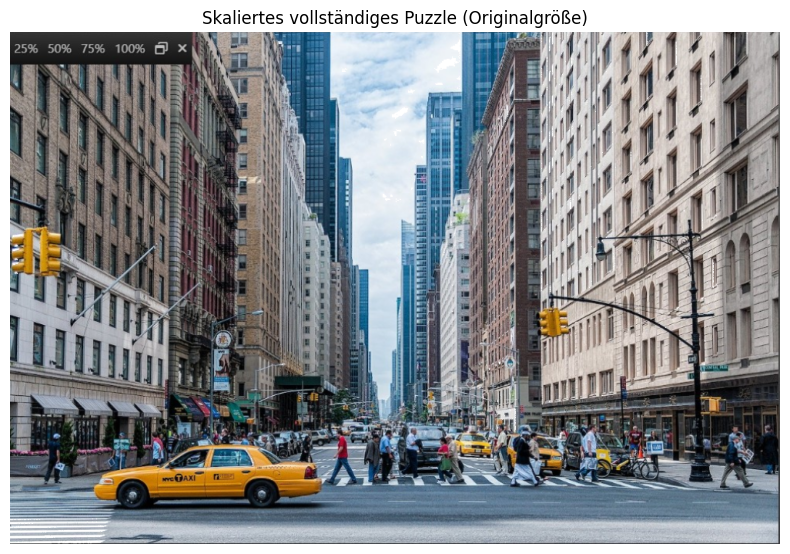

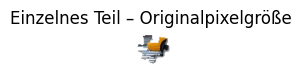

In [29]:
from matplotlib import pyplot as plt


puzzle_cols = 20
puzzle_rows = 15
target_full_width = 1000

# Lade vollständiges Puzzlebild
img_full = remove_white_background("fulltaxi.jpg")
resized_puzzle = resize_numpy_rgba_image(img_full, new_width=target_full_width)

# Lade einzelnes Teil
img_piece = remove_white_background("piecetaxi1.jpg", threshold=150)

# Skaliere Einzelteil passend zum Puzzle-Raster
resized_piece = resize_piece_to_fit_grid(
    piece_img=img_piece,
    full_img=img_full,
    cols=puzzle_cols,
    rows=puzzle_rows,
    full_target_width=target_full_width
)

# Anzeige – vollständiges Puzzle in Originalpixelgröße
h_puzzle, w_puzzle = resized_puzzle.shape[:2]
plt.figure(figsize=(w_puzzle / 100, h_puzzle / 100), dpi=100)
plt.imshow(resized_puzzle)
plt.title("Skaliertes vollständiges Puzzle (Originalgröße)")
plt.axis("off")

# Anzeige – einzelnes Teil in Originalpixelgröße
h_piece, w_piece = resized_piece.shape[:2]
plt.figure(figsize=(w_piece / 100, h_piece / 100), dpi=100)
plt.imshow(resized_piece)
plt.title("Einzelnes Teil – Originalpixelgröße")
plt.axis("off")

plt.show()


## Template Matching mit manueller MSE-Berechnung und Raster-Positionsvergleich

Im nächsten Schritt wollten wir herausfinden, **wo genau das freigestellte Puzzleteil im Gesamtbild vorkommt** – unabhängig von dessen Orientierung.

Dazu haben wir ein eigenes Template-Matching-Verfahren implementiert, das mit einer manuellen MSE-Berechnung (Mean Squared Error) arbeitet – ohne auf OpenCVs Standardfunktionen zurückzugreifen.

### Vorgehensweise:

1. 🔄 **Drehungen des Puzzleteils:**  
   Das Puzzleteil wird in vier Orientierungen getestet: 0°, 90°, 180°, 270°.  
   Bei jeder Drehung extrahieren wir nur den sichtbaren (nicht transparenten) Bereich, um den Vergleich auf reale Bildinhalte zu beschränken.

2. 🎯 **Rasterbasierter Vergleich mit dem Gesamtbild:**  
   Anstatt das Teil Pixel für Pixel zu verschieben, wird es **blockweise** über das Bild gelegt – jeweils um genau ein Feld weiter.  
   Dadurch wird jede mögliche Rasterposition (wie bei echten Puzzlefeldern) getestet.  
   An jeder Position vergleichen wir das Puzzleteil mit dem passenden Bildausschnitt und berechnen den **MSE**, also die durchschnittliche quadratische Abweichung der Farbwerte (RGB), nur in den sichtbaren Bereichen (Maske).

3. 🔥 **Heatmap-Visualisierung:**  
   Für jede Rotation wird eine Heatmap erzeugt, in der jede Rasterzelle den MSE-Wert für diese Position zeigt.  
   Je dunkler der Wert, desto besser passt das Teil an diese Stelle.

4. ✅ **Beste Übereinstimmung markieren:**  
   Die Position mit dem niedrigsten MSE-Wert wird als beste Übereinstimmung angenommen.  
   Diese wird im Originalbild mit einem grünen Rahmen markiert.  
   Dabei wird die Rasterposition korrekt in Bildkoordinaten zurückgerechnet (durch Multiplikation mit der Feldgröße).


C:\Users\STI\AppData\Local\Temp\ipykernel_31172\1419273014.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


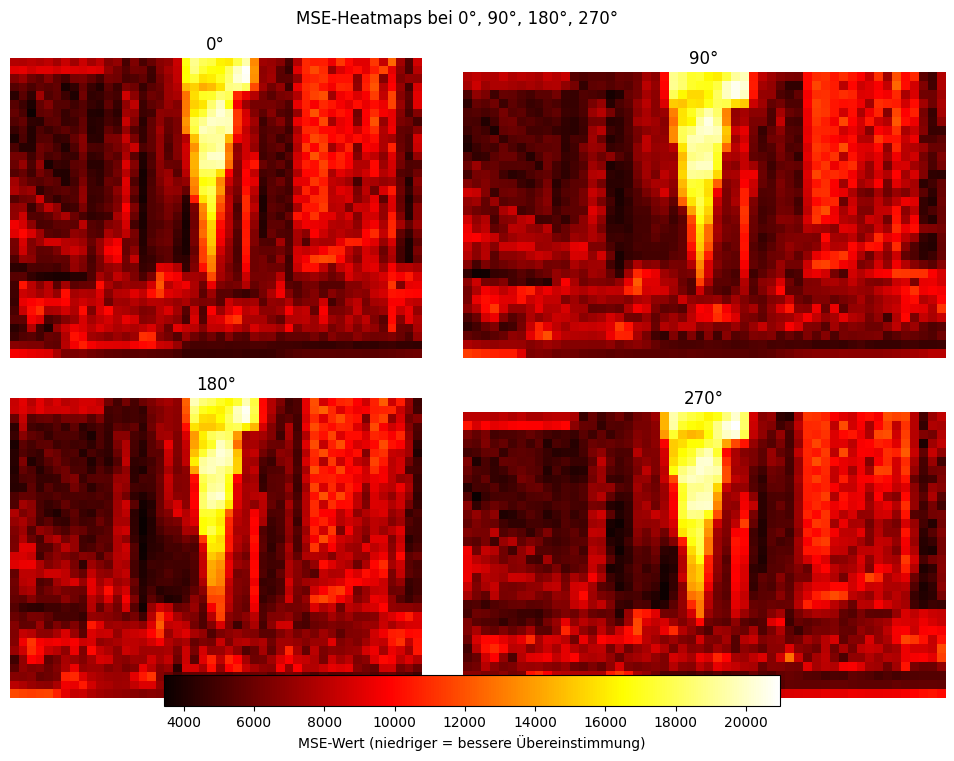

Beste Übereinstimmung:
  Score: 3443.1138
  Winkel: 180°
  Position: (x=300, y=270)
  Größe: 41x37


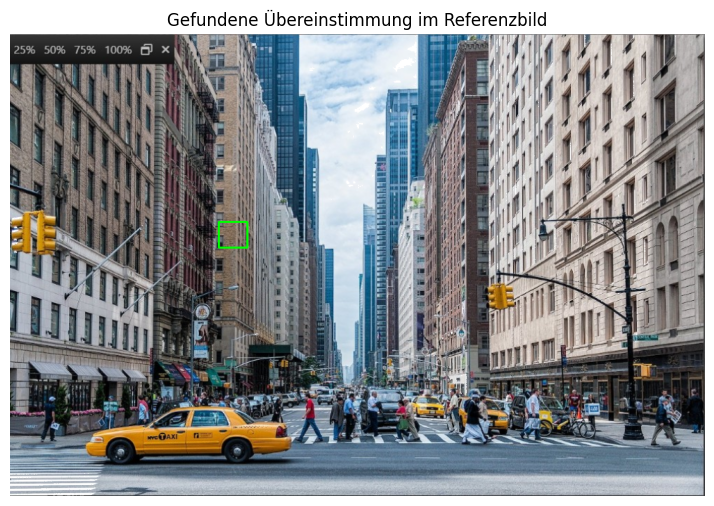

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


def extract_valid_template_region(tpl_rgba: np.ndarray, angle: int = 0,
                                  erode_iter: int = 3) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    rotiert den Stein, beschneidet ihn exakt und erstellt zwei Masken:
    - core_mask: Innenbereich ohne Rand (durch Erosion)
    - rim_mask : nur der Papp-Rand
    """
    h, w = tpl_rgba.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    rot = cv2.warpAffine(tpl_rgba, M, (w, h), flags=cv2.INTER_LINEAR,
                         borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0, 0))

    alpha = rot[..., 3]
    nz = np.argwhere(alpha > 0)
    if nz.size == 0:
        return None, None, None

    y0, x0 = nz.min(0)
    y1, x1 = nz.max(0) + 1
    tpl_crop = rot[y0:y1, x0:x1]

    full_mask = (tpl_crop[..., 3] > 0).astype(np.uint8)

    # Kernmaske erodieren, um Rand abzuschwächen
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    core_mask = cv2.erode(full_mask, kernel, iterations=erode_iter)
    rim_mask  = full_mask - core_mask

    return tpl_crop, core_mask, rim_mask


# ------------------------------------------------------------
# 2. Template-Matching (MAE mit Kern/Rand-Gewichtung)
# ------------------------------------------------------------
def template_match_mae(image: np.ndarray,
                       tpl: np.ndarray,
                       core_mask: np.ndarray,
                       rim_mask:  np.ndarray,
                       rim_weight: float = 0.2,
                       step_frac: float = 0.25) -> np.ndarray:
    """
    liefert eine MAE-Heatmap; niedriger = bessere Übereinstimmung
    """
    img_h, img_w, _ = image.shape
    th, tw, _       = tpl.shape

    step_y = max(1, int(th * step_frac))
    step_x = max(1, int(tw * step_frac))

    res_h = (img_h - th) // step_y + 1
    res_w = (img_w - tw) // step_x + 1
    heat  = np.full((res_h, res_w), np.inf, np.float32)

    tpl_core = tpl[..., :3].astype(np.float32)  # RGB
    tpl_rim  = tpl_core.copy()

    core_idx = core_mask.astype(bool)
    rim_idx  = rim_mask.astype(bool)

    for iy, y in enumerate(range(0, img_h - th + 1, step_y)):
        for ix, x in enumerate(range(0, img_w - tw + 1, step_x)):
            patch = image[y:y + th, x:x + tw, :3].astype(np.float32)

            # Absoluter Fehler
            diff = np.abs(patch - tpl_core)

            # Kern- und Rand-Fehler separat
            mae_core = diff[core_idx].mean() if core_idx.any() else 0.0
            mae_rim  = diff[rim_idx].mean()  if rim_idx.any()  else 0.0

            heat[iy, ix] = mae_core + rim_weight * mae_rim

    return heat, step_y, step_x


# ------------------------------------------------------------
# 3. Komplett­routine: Multi-Rotation, Heatmaps & Treffer
# ------------------------------------------------------------
def match_piece(img_rgba: np.ndarray,
                tpl_rgba: np.ndarray,
                rim_weight: float = 0.2,
                step_frac: float = 0.25):
    angles = (0, 90, 180, 270)
    heatmaps, step_sizes = [], []
    best_score, best_pos, best_angle, best_tpl = np.inf, None, None, None

    for ang in angles:
        tpl_crop, core, rim = extract_valid_template_region(tpl_rgba, ang)
        if tpl_crop is None:
            heatmaps.append(np.zeros((1, 1), np.float32))
            step_sizes.append((1, 1))
            continue

        hm, sy, sx = template_match_mae(img_rgba, tpl_crop, core, rim,
                                        rim_weight, step_frac)
        heatmaps.append(hm)
        step_sizes.append((sy, sx))

        min_val = hm.min()
        if min_val < best_score:
            best_score = min_val
            best_pos   = np.unravel_index(np.argmin(hm), hm.shape)
            best_angle = ang
            best_tpl   = tpl_crop.copy()

    # → Heatmaps anzeigen
    vmin, vmax = min(hm.min() for hm in heatmaps), max(hm.max() for hm in heatmaps)
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))
    ax = ax.ravel()
    for i, ang in enumerate(angles):
        im = ax[i].imshow(heatmaps[i], cmap='hot', vmin=vmin, vmax=vmax, interpolation='nearest')
        ax[i].set_title(f'{ang}°'); ax[i].axis('off')
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.08)
    cbar.set_label('MAE (niedriger = besser)')
    fig.suptitle('MAE-Heatmaps bei 0°, 90°, 180°, 270°')
    plt.tight_layout(); plt.subplots_adjust(top=0.92, bottom=0.12)
    plt.show()

    # → Treffer ins Bild zeichnen
    iy, ix               = best_pos
    sy, sx               = step_sizes[angles.index(best_angle)]
    h, w                 = best_tpl.shape[:2]
    y0, x0               = iy * sy, ix * sx
    y1, x1               = y0 + h, x0 + w
    img_draw             = img_rgba.copy()
    cv2.rectangle(img_draw, (x0, y0), (x1, y1), (0, 255, 0, 255), 2)

    print('Beste Übereinstimmung')
    print(' ├ Score  :', best_score)
    print(' ├ Winkel :', best_angle, '°')
    print(' └ Position:', (x0, y0), 'Größe:', (w, h))

    return img_draw
matched_result = show_manual_mse_heatmap_with_rotations_and_best_match(resized_puzzle, resized_piece)

plt.figure(figsize=(10, 6))
plt.imshow(matched_result)
plt.title("Gefundene Übereinstimmung im Referenzbild")
plt.axis("off")
plt.show()
